# Inflation - BCRP

In [27]:
import sys
from datetime import datetime as dt
from functools import reduce

import catppuccin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from bcrp_analytics.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use(catppuccin.PALETTE.mocha.identifier)

# Importing inflation series

In [3]:
ipc_series = {
    "PN38705PM": "ipc",
    "PN38706PM": "ipc_sin_alimentos_bebidas",
    "PN38707PM": "ipc_sin_alimentos_energia",
    "PN38708PM": "ipc_subyacente",
    "PN38709PM": "ipc_transables",
    "PN38710PM": "ipc_no_transables",
    "PN38711PM": "ipc_no_transables_sin_alimentos_bebidas",
    "PN39445PM": "ipc_alimentos_bebidas",
    "PN39447PM": "ipc_subyacente_sin_alimentos_bebidas",
    "PN39521PM": "ipc_alimentos_energia",
    "PN39522PM": "ipc_no_subyacente",
    "PN39523PM": "ipc_importado",
    # seasonally adjusted series
    "PN42107PM": "ipc_desestacionalizado",
}


inflation_series = {
    # oficial monthly inflation series
    "PN01271PM": "inflacion_mensual",
    # oficial accumulated inflation series
    "PN01272PM": "inflacion_acumulada",
    # oficial yoy inflation series
    "PN01273PM": "inflacion_12m",
}

# series to test
adquirentes_facilitadores_pago_series = {
    "PN42689EM": "monto_total_adqfac",
    # instrumentos de pago de alto y bajo valor
    "PN42156EM": "alto_valor",
    "PN42160EM": "bajo_valor",
}

In [ ]:
df_ipc_series = build_bcrp_dataset(ipc_series)
df_inflation_series = build_bcrp_dataset(inflation_series)
df_adquirentes_facilitadores = build_bcrp_dataset(adquirentes_facilitadores_pago_series)

In [17]:
(116.81 / 115.89 - 1) * 100

0.7938562429890439

In [5]:
df_ipc_series.head()

,period,ipc,ipc_sin_alimentos_bebidas,ipc_sin_alimentos_energia,ipc_subyacente,ipc_transables,ipc_no_transables,ipc_no_transables_sin_alimentos_bebidas,ipc_alimentos_bebidas,ipc_subyacente_sin_alimentos_bebidas,ipc_alimentos_energia,ipc_no_subyacente,ipc_importado,ipc_desestacionalizado
0,2026-04-01,120.21,115.98,117.34,118.15,116.66,121.78,118.11,126.57,113.85,123.76,124.58,109.39,119.91
1,2026-03-01,119.59,115.00,116.33,117.80,116.37,121.01,116.81,126.49,113.56,123.62,123.40,109.22,119.28
2,2026-02-01,116.81,112.18,113.97,116.91,114.34,117.90,113.76,123.76,112.70,120.32,116.61,104.39,117.14
3,2026-01-01,116.01,111.88,113.56,116.65,114.04,116.87,113.42,122.21,112.46,119.03,114.65,104.27,116.35
4,2025-12-01,115.89,111.85,113.52,116.49,113.93,116.76,113.44,121.97,112.37,118.83,114.63,104.11,116.12


In [13]:
df_inflation_series.head()

,period,inflacion_mensual,inflacion_acumulada,inflacion_12m
0,2026-04-01,0.52,3.72,4.01
1,2026-03-01,2.38,3.19,3.80
2,2026-02-01,0.69,0.79,2.21
3,2026-01-01,0.10,0.10,1.70
4,2025-12-01,0.24,1.51,1.51


In [7]:
df_adquirentes_facilitadores.head()

,period,monto_total_adqfac,alto_valor,bajo_valor
0,2026-03-01,"13,167.96","478,458.55","417,155.45"
1,2026-02-01,"11,697.08","411,779.84","377,297.19"
2,2026-01-01,"12,252.01","398,930.84","394,384.29"
3,2025-12-01,"14,927.05","462,444.46","458,953.59"
4,2025-11-01,"12,200.23","398,541.09","374,481.11"


# Comparing calculated inflation vs BCRP inflation series

In [41]:
# we need to have the first series at the beginning to apply the function pct _chagnge (remember that in pandas the first rows are the the latest)
df_ipc_series_calculated = df_ipc_series.sort_values("period")

# monthly pct change
df_ipc_series_calculated["calculated_inflation"] = (
    df_ipc_series_calculated["ipc"].pct_change() * 100
)
display(df_ipc_series_calculated[["period", "ipc", "calculated_inflation"]].tail(5))

# 12m pct change

df_ipc_series_calculated["12m_calculated_inflation"] = (
    df_ipc_series_calculated["ipc"].pct_change(12) * 100
)
display(df_ipc_series_calculated[["period", "ipc", "12m_calculated_inflation"]].tail(5))

# accumulated inflation

,period,ipc,calculated_inflation
4,2025-12-01,115.89,0.24
3,2026-01-01,116.01,0.10
2,2026-02-01,116.81,0.69
1,2026-03-01,119.59,2.38
0,2026-04-01,120.21,0.52


,period,ipc,12m_calculated_inflation
4,2025-12-01,115.89,1.51
3,2026-01-01,116.01,1.70
2,2026-02-01,116.81,2.21
1,2026-03-01,119.59,3.80
0,2026-04-01,120.21,4.01


In [ ]:
df_ipc_series_calculated["year"] = df_ipc_series_calculated["period"].dt.year
df_ipc_series_calculated["month"] = df_ipc_series_calculated["period"].dt.month

df_decembers = df_ipc_series_calculated[df_ipc_series_calculated["month"] == 12][
    ["year", "ipc"]
].drop_duplicates()
df_decembers["year"] = df_decembers["year"] + 1

df_decembers = df_decembers.rename(columns={"ipc": "ipc_decembers"})

df_ipc_series_calculated = df_ipc_series_calculated.merge(
    df_decembers, on="year", how="left"
)


df_ipc_series_calculated["accumulated_inflation"] = (
    df_ipc_series_calculated["ipc"] / df_ipc_series_calculated["ipc_decembers"] - 1
) * 100

df_ipc_series_calculated[
    ["period", "ipc", "ipc_decembers", "accumulated_inflation"]
].tail()

,period,ipc,ipc_decembers,accumulated_inflation
55,2025-12-01,115.89,114.17,1.51
56,2026-01-01,116.01,115.89,0.10
57,2026-02-01,116.81,115.89,0.79
58,2026-03-01,119.59,115.89,3.19
59,2026-04-01,120.21,115.89,3.72


# Applying defaltion to payment system series

In [45]:
df_adquirentes_facilitadores_deflation = df_adquirentes_facilitadores.merge(
    df_ipc_series, on="period", how="left"
)

df_adquirentes_facilitadores_deflation.head()

,period,monto_total_adqfac,alto_valor,bajo_valor,ipc,ipc_sin_alimentos_bebidas,ipc_sin_alimentos_energia,ipc_subyacente,ipc_transables,ipc_no_transables,ipc_no_transables_sin_alimentos_bebidas,ipc_alimentos_bebidas,ipc_subyacente_sin_alimentos_bebidas,ipc_alimentos_energia,ipc_no_subyacente,ipc_importado,ipc_desestacionalizado
0,2026-03-01,"13,167.96","478,458.55","417,155.45",119.59,115.00,116.33,117.80,116.37,121.01,116.81,126.49,113.56,123.62,123.40,109.22,119.28
1,2026-02-01,"11,697.08","411,779.84","377,297.19",116.81,112.18,113.97,116.91,114.34,117.90,113.76,123.76,112.70,120.32,116.61,104.39,117.14
2,2026-01-01,"12,252.01","398,930.84","394,384.29",116.01,111.88,113.56,116.65,114.04,116.87,113.42,122.21,112.46,119.03,114.65,104.27,116.35
3,2025-12-01,"14,927.05","462,444.46","458,953.59",115.89,111.85,113.52,116.49,113.93,116.76,113.44,121.97,112.37,118.83,114.63,104.11,116.12
4,2025-11-01,"12,200.23","398,541.09","374,481.11",115.61,111.37,112.99,116.22,113.94,116.35,112.75,121.98,112.08,118.85,114.33,104.37,115.89


In [47]:
df_adquirentes_facilitadores_deflation["monto_total_adqfac_deflated"] = (
    df_adquirentes_facilitadores_deflation["monto_total_adqfac"]
    / df_adquirentes_facilitadores_deflation["ipc"]
) * 100


df_adquirentes_facilitadores_deflation[
    ["period", "monto_total_adqfac", "monto_total_adqfac_deflated"]
].head()

,period,monto_total_adqfac,monto_total_adqfac_deflated
0,2026-03-01,"13,167.96","11,011.02"
1,2026-02-01,"11,697.08","10,013.74"
2,2026-01-01,"12,252.01","10,561.56"
3,2025-12-01,"14,927.05","12,879.84"
4,2025-11-01,"12,200.23","10,552.69"


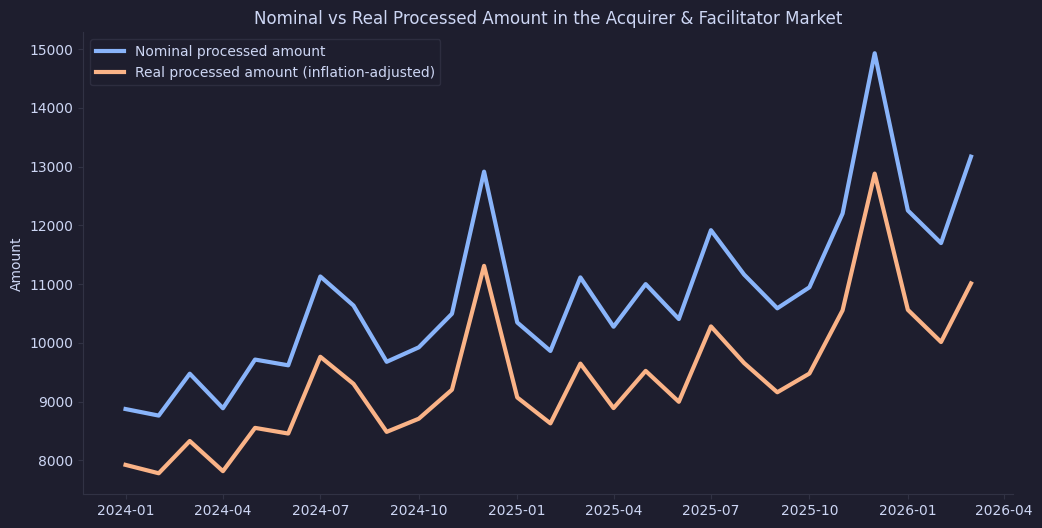

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_adquirentes_facilitadores_deflation["period"],
    df_adquirentes_facilitadores_deflation["monto_total_adqfac"],
    label="Nominal processed amount",
    linewidth=3,
)

ax.plot(
    df_adquirentes_facilitadores_deflation["period"],
    df_adquirentes_facilitadores_deflation["monto_total_adqfac_deflated"],
    label="Real processed amount (inflation-adjusted)",
    linewidth=3,
)

ax.set_title("Nominal vs Real Processed Amount in the Acquirer & Facilitator Market")

ax.set_ylabel("Amount")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

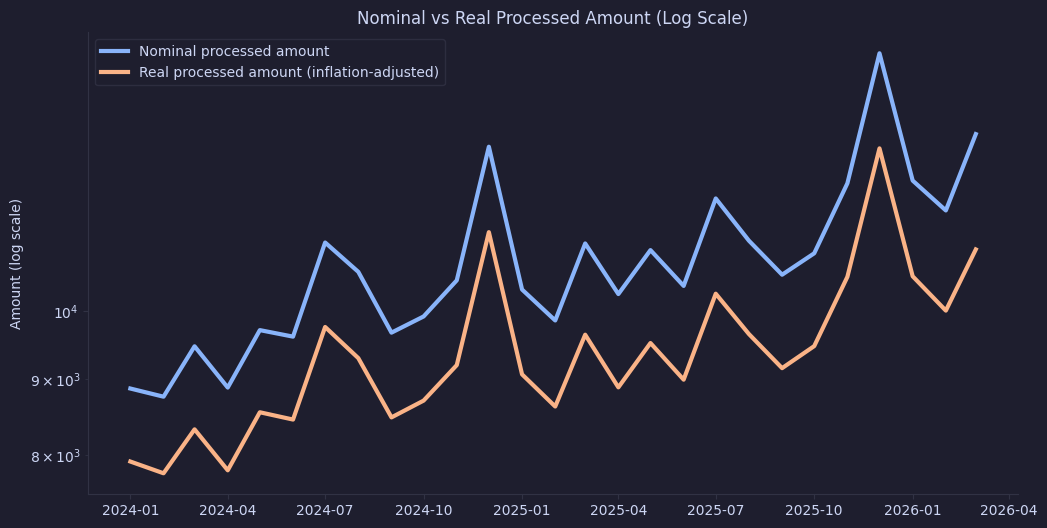

In [51]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_adquirentes_facilitadores_deflation["period"],
    df_adquirentes_facilitadores_deflation["monto_total_adqfac"],
    label="Nominal processed amount",
    linewidth=3,
)

ax.plot(
    df_adquirentes_facilitadores_deflation["period"],
    df_adquirentes_facilitadores_deflation["monto_total_adqfac_deflated"],
    label="Real processed amount (inflation-adjusted)",
    linewidth=3,
)

# log scale
ax.set_yscale("log")

ax.set_title("Nominal vs Real Processed Amount (Log Scale)")

ax.set_ylabel("Amount (log scale)")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()